<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/lab%2015/Lab_15_The_Polynomial_Trap_%E2%80%94_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [10]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


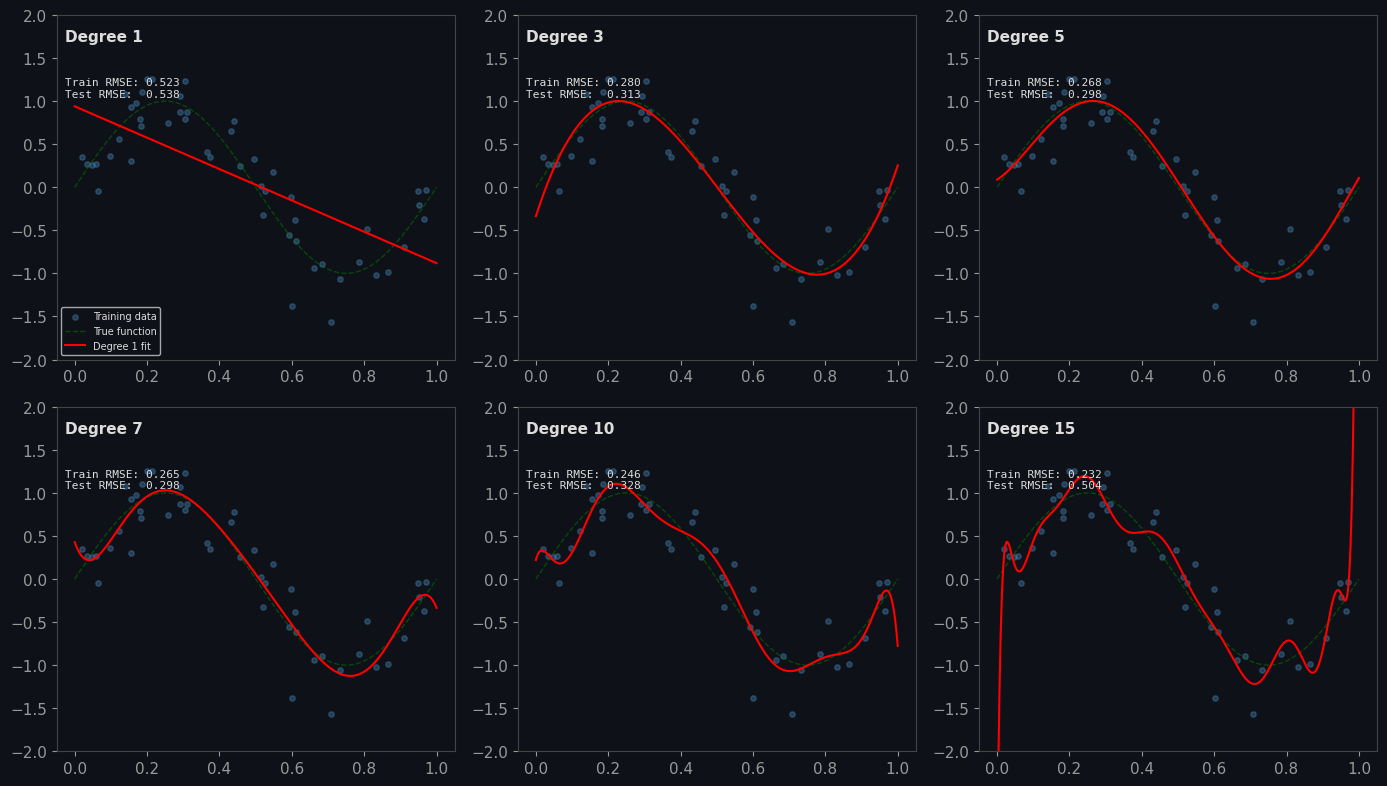

In [11]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

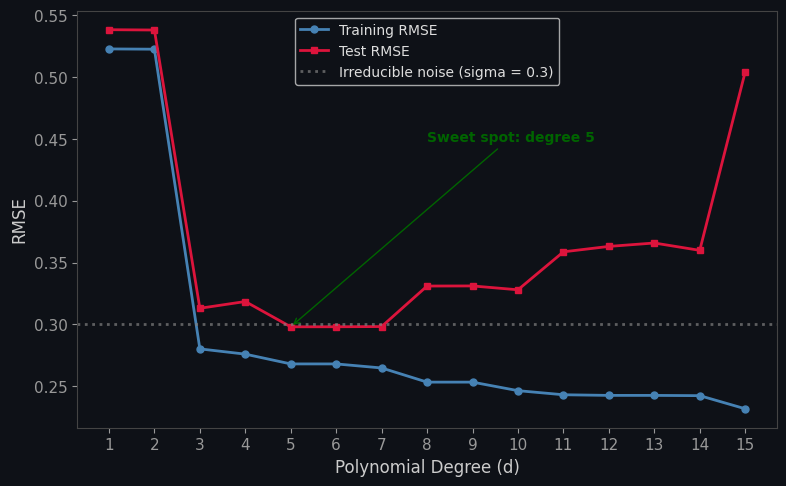

In [12]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(_x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [14]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


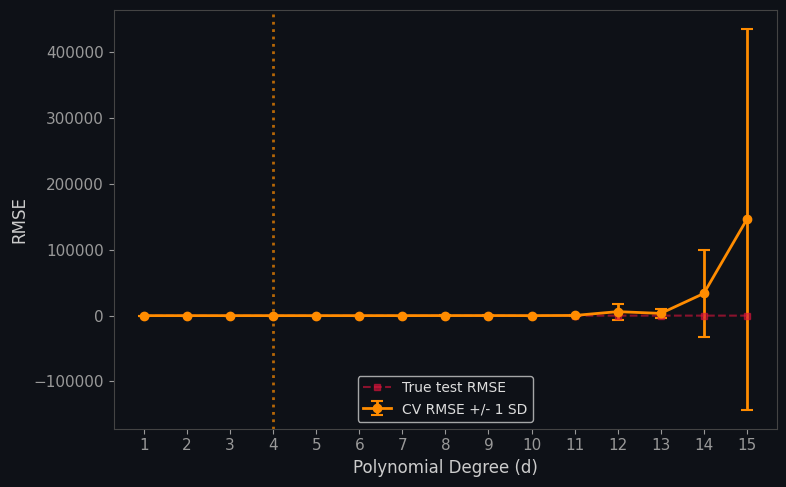

CV-selected degree: 4
True optimal degree: 5


In [15]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [16]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [17]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


In [23]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║         BIAS–VARIANCE TRADEOFF EXPLORER  ·  Google Colab Edition        ║
# ║  Paste this entire cell into Colab and run it.  No Streamlit needed.    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
# All libraries come pre-installed on Colab — nothing extra to pip install.
# Uses: numpy · scikit-learn · matplotlib · ipywidgets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines   import Line2D
import warnings, functools

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model  import LinearRegression
from sklearn.pipeline      import make_pipeline
from sklearn.metrics       import mean_squared_error

import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings("ignore")          # suppress sklearn ill-conditioned warnings

# ── Enable inline interactive backend ─────────────────────────────────────────
try:
    from google.colab import output as _colab_output
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

# Use widget backend for interactivity
import matplotlib
matplotlib.use("module://ipympl.backend_nbagg") if not _IN_COLAB else None
# Colab uses its own widget bridge; %matplotlib widget works there too.

# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONSTANTS
# ══════════════════════════════════════════════════════════════════════════════
DEGREE_RANGE  = np.arange(1, 16)           # degrees 1 – 15
X_DENSE       = np.linspace(0, 1, 300)     # evaluation grid
Y_TRUE        = np.sin(2 * np.pi * X_DENSE)
N_BOOTSTRAP   = 100
RNG_SEED      = 42

PAL = dict(
    bg       = "#0d1117",
    panel    = "#161b22",
    border   = "#30363d",
    data     = "#58a6ff",
    true_fn  = "#3fb950",
    fit      = "#f78166",
    train    = "#58a6ff",
    test     = "#ff7b72",
    vline    = "#e3b341",
    bias2    = "#f78166",
    variance = "#79c0ff",
    mse      = "#56d364",
    text     = "#c9d1d9",
    subtext  = "#8b949e",
)

plt.rcParams.update({
    "figure.facecolor"  : PAL["bg"],
    "axes.facecolor"    : PAL["panel"],
    "axes.edgecolor"    : PAL["border"],
    "axes.labelcolor"   : PAL["text"],
    "axes.titlecolor"   : PAL["text"],
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "xtick.color"       : PAL["subtext"],
    "ytick.color"       : PAL["subtext"],
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "text.color"        : PAL["text"],
    "grid.color"        : PAL["border"],
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.6,
    "lines.linewidth"   : 2,
    "font.family"       : "monospace",
    "legend.framealpha" : 0.85,
    "legend.facecolor"  : PAL["panel"],
    "legend.edgecolor"  : PAL["border"],
    "legend.fontsize"   : 9,
})

# ══════════════════════════════════════════════════════════════════════════════
# CORE FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def generate_data(n, sigma, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    X_tr = rng.uniform(0, 1, n)
    y_tr = np.sin(2 * np.pi * X_tr) + rng.normal(0, sigma, n)
    X_te = rng.uniform(0, 1, 200)
    y_te = np.sin(2 * np.pi * X_te) + rng.normal(0, sigma, 200)
    return X_tr, y_tr, X_te, y_te


def fit_poly(degree, X, y):
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X.reshape(-1, 1), y)
    return model


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def complexity_curves(n, sigma):
    X_tr, y_tr, X_te, y_te = generate_data(n, sigma)
    tr, te = [], []
    for d in DEGREE_RANGE:
        m = fit_poly(d, X_tr, y_tr)
        tr.append(rmse(y_tr, m.predict(X_tr.reshape(-1,1))))
        te.append(rmse(y_te, m.predict(X_te.reshape(-1,1))))
    return np.array(tr), np.array(te)


# Simple manual cache keyed by (n, sigma)
_bv_cache = {}

def bias_variance_decomp(n, sigma):
    key = (n, round(sigma, 2))
    if key in _bv_cache:
        return _bv_cache[key]

    rng    = np.random.default_rng(RNG_SEED)
    N_POOL = max(n * 5, 500)
    X_pool = rng.uniform(0, 1, N_POOL)
    y_pool = np.sin(2*np.pi*X_pool) + rng.normal(0, sigma, N_POOL)

    biases, variances, mses = [], [], []
    for d in DEGREE_RANGE:
        preds = np.zeros((N_BOOTSTRAP, len(X_DENSE)))
        for b in range(N_BOOTSTRAP):
            idx  = rng.integers(0, N_POOL, size=n)
            try:
                m       = fit_poly(d, X_pool[idx], y_pool[idx])
                preds[b] = m.predict(X_DENSE.reshape(-1,1))
            except Exception:
                preds[b] = np.nan
        mean_p   = np.nanmean(preds, axis=0)
        bias2    = float(np.mean((mean_p - Y_TRUE)**2))
        variance = float(np.mean(np.nanvar(preds, axis=0)))
        mses.append(bias2 + variance + sigma**2)
        biases.append(bias2)
        variances.append(variance)

    result = np.array(biases), np.array(variances), np.array(mses)
    _bv_cache[key] = result
    return result


# ══════════════════════════════════════════════════════════════════════════════
# PLOT BUILDER  – draws all 3 panels into one figure
# ══════════════════════════════════════════════════════════════════════════════

def build_figure(degree, sigma, n_train, bv_data):
    X_tr, y_tr, X_te, y_te = generate_data(n_train, sigma)
    model   = fit_poly(degree, X_tr, y_tr)
    tr_rmse, te_rmse        = complexity_curves(n_train, sigma)
    biases, variances, mses = bv_data

    train_err = rmse(y_tr, model.predict(X_tr.reshape(-1,1)))
    test_err  = rmse(y_te, model.predict(X_te.reshape(-1,1)))
    idx = degree - 1

    # ── Layout: 2 columns top, 1 wide bottom ──────────────────────────────
    fig = plt.figure(figsize=(14, 10), facecolor=PAL["bg"])
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        top=0.91, bottom=0.07,
        left=0.06, right=0.97,
        hspace=0.45, wspace=0.32
    )
    ax_fit    = fig.add_subplot(gs[0, 0])
    ax_curve  = fig.add_subplot(gs[0, 1])
    ax_bv     = fig.add_subplot(gs[1, :])    # spans both columns

    # ── Big title ─────────────────────────────────────────────────────────
    fig.text(
        0.5, 0.965,
        "BIAS – VARIANCE  TRADEOFF  EXPLORER",
        ha="center", va="top",
        fontsize=15, fontweight="bold",
        color=PAL["text"], fontfamily="monospace"
    )
    fig.text(
        0.5, 0.945,
        f"degree={degree}   σ={sigma:.2f}   n={n_train}",
        ha="center", va="top",
        fontsize=10, color=PAL["subtext"], fontfamily="monospace"
    )

    # ── Panel 1 : Polynomial fit ──────────────────────────────────────────
    ax_fit.scatter(X_tr, y_tr, s=22, alpha=0.7,
                   color=PAL["data"], zorder=3, label="train data")
    ax_fit.plot(X_DENSE, Y_TRUE,
                color=PAL["true_fn"], lw=2, label="sin(2πx)", zorder=2)
    y_fit = model.predict(X_DENSE.reshape(-1,1))
    ax_fit.plot(X_DENSE, y_fit,
                color=PAL["fit"], lw=2.2, ls="--",
                label=f"Poly deg {degree}", zorder=4)
    ax_fit.set_xlim(0, 1);  ax_fit.set_ylim(-3, 3)
    ax_fit.set_xlabel("x");  ax_fit.set_ylabel("y")
    ax_fit.set_title(f"▸ POLYNOMIAL FIT", loc="left", pad=8)
    ax_fit.grid(True)
    ax_fit.legend()

    # small metric box
    ax_fit.text(0.97, 0.97,
                f"train RMSE {train_err:.4f}\n test RMSE {test_err:.4f}",
                transform=ax_fit.transAxes,
                ha="right", va="top", fontsize=8, fontfamily="monospace",
                color=PAL["text"],
                bbox=dict(boxstyle="round,pad=0.4",
                          facecolor=PAL["bg"], edgecolor=PAL["border"], alpha=0.9))

    # ── Panel 2 : Complexity curve ────────────────────────────────────────
    ax_curve.plot(DEGREE_RANGE, tr_rmse, "o-",
                  color=PAL["train"], ms=5, label="train RMSE")
    ax_curve.plot(DEGREE_RANGE, te_rmse, "s-",
                  color=PAL["test"],  ms=5, label="test RMSE")
    ax_curve.axvline(degree, color=PAL["vline"], ls=":", lw=2,
                     label=f"d={degree}")
    ax_curve.set_xlabel("polynomial degree")
    ax_curve.set_ylabel("RMSE")
    ax_curve.set_title("▸ COMPLEXITY CURVE", loc="left", pad=8)
    ax_curve.set_xticks(DEGREE_RANGE)
    ax_curve.grid(True)
    ax_curve.legend()

    # ── Panel 3 : Bias–Variance decomposition ─────────────────────────────
    ax_bv.plot(DEGREE_RANGE, biases,    "o-",
               color=PAL["bias2"],    ms=5, label="Bias²")
    ax_bv.plot(DEGREE_RANGE, variances, "s-",
               color=PAL["variance"], ms=5, label="Variance")
    ax_bv.plot(DEGREE_RANGE, mses,      "^-",
               color=PAL["mse"],      ms=5, label="Bias² + Var + σ²  (≈ MSE)")
    ax_bv.axvline(degree, color=PAL["vline"], ls=":", lw=2,
                  label=f"d={degree}")
    ax_bv.set_xlabel("polynomial degree")
    ax_bv.set_ylabel("error")
    ax_bv.set_title("▸ BOOTSTRAP BIAS²–VARIANCE DECOMPOSITION  "
                    f"(100 resamples, cached per [n, σ])",
                    loc="left", pad=8)
    ax_bv.set_xticks(DEGREE_RANGE)
    ax_bv.grid(True)
    ax_bv.legend(ncol=4)

    # Annotate selected degree values
    b2, var, mse_val = biases[idx], variances[idx], mses[idx]
    check = abs(b2 + var + sigma**2 - mse_val)
    sign  = "✓" if check < 0.01 else "~"
    ax_bv.text(0.99, 0.97,
               f"@ d={degree}\n"
               f"Bias²    = {b2:.4f}\n"
               f"Variance = {var:.4f}\n"
               f"σ²       = {sigma**2:.4f}\n"
               f"MSE      = {mse_val:.4f}  {sign}",
               transform=ax_bv.transAxes,
               ha="right", va="top", fontsize=8.5, fontfamily="monospace",
               color=PAL["text"],
               bbox=dict(boxstyle="round,pad=0.5",
                         facecolor=PAL["bg"], edgecolor=PAL["border"], alpha=0.92))

    plt.close(fig)
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# WIDGET LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

style   = {"description_width": "140px"}
layout  = widgets.Layout(width="420px")

w_degree = widgets.IntSlider(
    value=4, min=1, max=15, step=1,
    description="Poly Degree",
    continuous_update=False,
    style=style, layout=layout
)
w_sigma = widgets.FloatSlider(
    value=0.3, min=0.10, max=1.0, step=0.05,
    description="Noise σ",
    readout_format=".2f",
    continuous_update=False,
    style=style, layout=layout
)
w_n = widgets.IntSlider(
    value=40, min=20, max=200, step=10,
    description="Train points n",
    continuous_update=False,
    style=style, layout=layout
)

status_out = widgets.Output()   # spinner / status messages
plot_out   = widgets.Output()   # figure lives here

controls = widgets.VBox(
    [
        widgets.HTML("<b style='font-family:monospace;font-size:13px;"
                     "color:#c9d1d9'>⚙  CONTROLS</b>"),
        w_degree, w_sigma, w_n,
        widgets.HTML(
            "<span style='font-family:monospace;font-size:10px;"
            "color:#8b949e'>"
            "Drag sliders · bootstrap panel is cached<br>"
            "per (n, σ) — first run may take ~5 s</span>"
        ),
        status_out,
    ],
    layout=widgets.Layout(
        padding="12px", border="1px solid #30363d",
        border_radius="8px", background="#161b22",
        margin="0 0 14px 0"
    )
)

# ── Update logic ──────────────────────────────────────────────────────────────

def refresh(change=None):
    degree  = w_degree.value
    sigma   = w_sigma.value
    n_train = w_n.value

    with status_out:
        clear_output(wait=True)
        key = (n_train, round(sigma, 2))
        if key not in _bv_cache:
            print(f"⏳  computing bootstrap for n={n_train}, σ={sigma:.2f} …")

    bv_data = bias_variance_decomp(n_train, sigma)   # uses cache after 1st call

    fig = build_figure(degree, sigma, n_train, bv_data)

    with plot_out:
        clear_output(wait=True)
        display(fig)

    with status_out:
        clear_output(wait=True)
        b2  = bv_data[0][degree-1]
        var = bv_data[1][degree-1]
        mse = bv_data[2][degree-1]
        chk = abs(b2 + var + sigma**2 - mse)
        tick = "✅" if chk < 0.01 else "⚠️"
        print(f"{tick}  |Bias²+Var+σ²−MSE| = {chk:.5f}")

w_degree.observe(refresh, names="value")
w_sigma .observe(refresh, names="value")
w_n     .observe(refresh, names="value")

# ── Render ────────────────────────────────────────────────────────────────────
display(controls, plot_out)
refresh()   # draw on load

Output()